# Laboratorio adicional: matrices dispersas y estructura productiva del Perú

**Curso:** Métodos Numéricos — Facultad de Economía, Universidad del Pacífico  
**Periodo:** 2026-2  
**Duración sugerida:** 150–200 minutos  
**Herramientas:** NumPy, pandas, SciPy, Matplotlib y openpyxl

Trabajaremos con la **Matriz Insumo Producto a Precios Básicos Total del Perú,
año 2007**, publicada por el Instituto Nacional de Estadística e Informática
(INEI), nivel 101 productos por 101 productos y expresada en millones de nuevos
soles.

Fuente oficial:
https://www1.inei.gob.pe/estadisticas/indice-tematico/matriz-insumo-producto-13673/

El archivo original del INEI se distribuye junto con este cuaderno para que el
laboratorio sea reproducible sin conexión.

## 0. Objetivos

Al terminar, el estudiante debe poder:

- medir densidad y dispersidad de una matriz económica;
- distinguir representaciones COO, CSR y CSC;
- comparar memoria densa y dispersa;
- visualizar el patrón de relaciones intersectoriales;
- construir la matriz de coeficientes técnicos de Leontief;
- resolver un sistema disperso con métodos directos e iterativos;
- interpretar cómo un umbral cambia una red económica.

Un cero estructural significa ausencia de flujo registrado. Aplicar un umbral
crea una aproximación y debe documentarse: no es una operación inocua.

In [1]:
from pathlib import Path
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.csgraph import connected_components

np.set_printoptions(precision=5, suppress=True, linewidth=110)
plt.rcParams["figure.dpi"] = 110

nombre_archivo = "inei_mip_2007_precios_basicos_total.xlsx"
candidatos = [Path("datos") / nombre_archivo,
              Path("laboratorios") / "datos" / nombre_archivo]
ARCHIVO = next((p for p in candidatos if p.exists()), None)
if ARCHIVO is None:
    raise FileNotFoundError("No se encontró el archivo oficial del INEI")

print("SciPy:", scipy.__version__)
print("Archivo:", ARCHIVO)
print("SHA-256:", hashlib.sha256(ARCHIVO.read_bytes()).hexdigest())

SciPy: 1.18.1
Archivo: datos/inei_mip_2007_precios_basicos_total.xlsx
SHA-256: fb517b00ee59effe920426d2b3792574fa2131b2fbec31c02d7755649050f00f


## 1. Lectura y extracción de la tabla

El libro oficial contiene títulos, oferta, demanda intermedia y demanda final.
Para este laboratorio:

- filas 11–111: 101 productos;
- columnas 13–113: demanda intermedia \(Z\);
- columna 124: demanda final total \(d\);
- columna 125: demanda total o producción total \(x\).

Los índices se refieren a posiciones observadas en el archivo original,
contadas desde cero en pandas.

In [2]:
hoja = "MIP_Basico_2007_Corrientes_101_"
raw = pd.read_excel(ARCHIVO, sheet_name=hoja, header=None)
print("Dimensión de la hoja original:", raw.shape)
raw.iloc[:14, :8]

Dimensión de la hoja original: (163, 129)


,0,1,2,3,4,5,6,7
0,Matriz Insumo Producto a Precios Básicos Total...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A precios Corrientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Nivel: 101 Productos y 101 Productos,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Información en Millones de Nuevos Soles,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,Producción,319693,NaN,NaN,NaN,NaN,NaN
6,2,Gasto,319693,NaN,NaN,NaN,NaN,NaN
7,3,Ingreso,319693,NaN,NaN,NaN,NaN,NaN
8,Nivel,Oferta,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Codigo,Descripción,Producción,Importaciones,Derechos de Importación,Margen de Transporte,Margen de Comercio


In [3]:
filas = slice(11, 112)
codigos = raw.iloc[filas, 1].astype(str).to_numpy()
sectores = raw.iloc[filas, 2].astype(str).to_numpy()
Z = raw.iloc[filas, 13:114].fillna(0).to_numpy(dtype=float)
demanda_final = pd.to_numeric(raw.iloc[filas, 124], errors="coerce").fillna(0).to_numpy()
produccion = pd.to_numeric(raw.iloc[filas, 125], errors="coerce").fillna(0).to_numpy()

print("Z:", Z.shape)
print("Sectores:", sectores.size)
print("Producción mínima y máxima:", produccion.min(), produccion.max())
assert Z.shape == (101, 101)
assert np.all(produccion > 0)

Z: (101, 101)
Sectores: 101
Producción mínima y máxima: 32 48826


In [4]:
balance = Z.sum(axis=1) + demanda_final
error_balance = np.linalg.norm(balance - produccion) / np.linalg.norm(produccion)
print("Error relativo del equilibrio Z·1 + d = x:", error_balance)
print("Máxima diferencia absoluta:", np.max(np.abs(balance - produccion)))
assert np.allclose(balance, produccion)

Error relativo del equilibrio Z·1 + d = x: 0.0
Máxima diferencia absoluta: 0.0


## 2. ¿Qué tan dispersa es la matriz?

Para una matriz \(m\times n\):
\[
\text{densidad}=\frac{\operatorname{nnz}(A)}{mn},
\qquad
\text{dispersidad}=1-\text{densidad}.
\]

La utilidad de un formato disperso depende del número de no nulos y no solo del
tamaño total.

In [5]:
nnz = np.count_nonzero(Z)
densidad = nnz / Z.size
print("Entradas totales:", Z.size)
print("No nulos:", nnz)
print(f"Densidad: {densidad:.2%}")
print(f"Dispersidad: {1-densidad:.2%}")

Entradas totales: 10201
No nulos: 3769
Densidad: 36.95%
Dispersidad: 63.05%


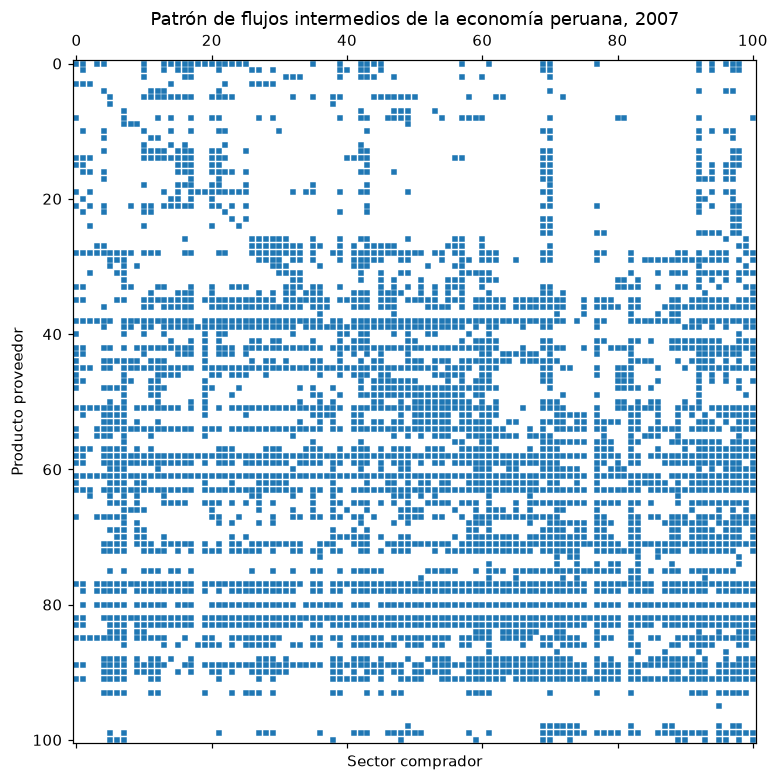

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.spy(Z, markersize=2.3, color="tab:blue")
ax.set_title("Patrón de flujos intermedios de la economía peruana, 2007")
ax.set_xlabel("Sector comprador")
ax.set_ylabel("Producto proveedor")
plt.tight_layout()
plt.show()

### Umbral económico para explorar la red

La unidad es un millón de nuevos soles. Conservaremos temporalmente relaciones
de al menos 50 millones para obtener una red visual más legible. La matriz
original se mantiene intacta para los cálculos de Leontief.

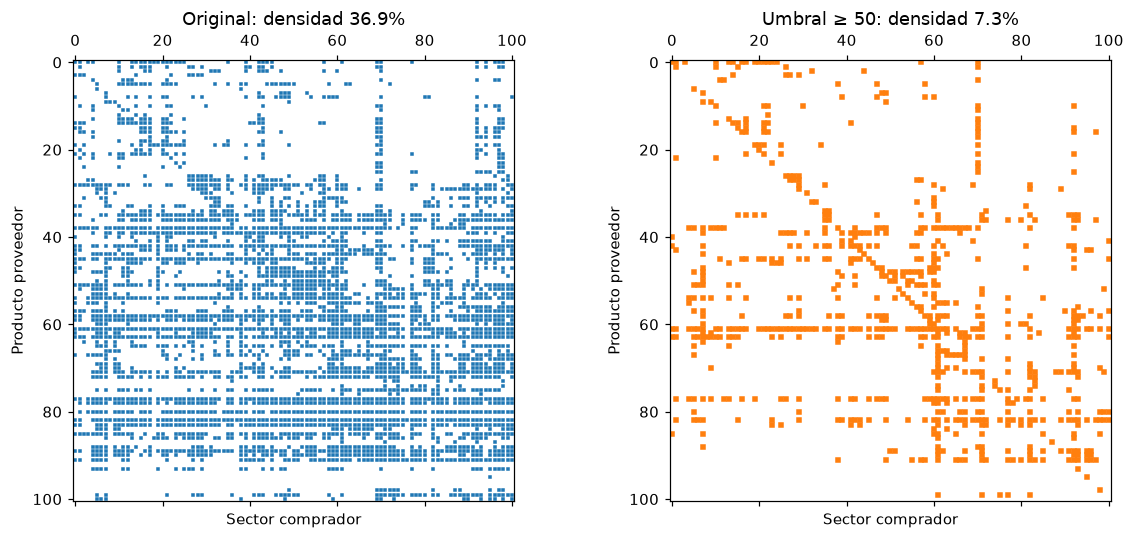

In [7]:
umbral = 50.0
Z_umbral = Z.copy()
Z_umbral[Z_umbral < umbral] = 0.0

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].spy(Z, markersize=1.5, color="tab:blue")
axes[0].set_title(f"Original: densidad {np.count_nonzero(Z)/Z.size:.1%}")
axes[1].spy(Z_umbral, markersize=2.2, color="tab:orange")
axes[1].set_title(f"Umbral ≥ {umbral:.0f}: densidad {np.count_nonzero(Z_umbral)/Z.size:.1%}")
for ax in axes:
    ax.set_xlabel("Sector comprador")
    ax.set_ylabel("Producto proveedor")
plt.tight_layout()
plt.show()

### Actividad 1

Repita la visualización con umbrales de 0, 10, 100 y 500 millones. Para cada
valor reporte densidad, número de sectores aislados y porcentaje del valor total
eliminado. ¿Cuál es el costo económico de hacer la red más legible?

## 3. COO, CSR y CSC

- **COO** almacena ternas fila–columna–valor y facilita construir la matriz.
- **CSR** agrupa por filas; es eficiente para productos matriz–vector y cortes
  por filas.
- **CSC** agrupa por columnas; favorece cortes y operaciones por columnas.

In [8]:
M_demo = np.array([[0., 5., 0., 0.],
                   [2., 0., 0., 7.],
                   [0., 0., 3., 0.],
                   [0., 1., 0., 4.]])
coo = sp.coo_matrix(M_demo)
csr = coo.tocsr()
csc = coo.tocsc()

print("COO filas   :", coo.row)
print("COO columnas:", coo.col)
print("COO datos   :", coo.data)
print("CSR data    :", csr.data)
print("CSR indices :", csr.indices)
print("CSR indptr  :", csr.indptr)
print("CSC indptr  :", csc.indptr)

COO filas   : [0 1 1 2 3 3]
COO columnas: [1 0 3 2 1 3]
COO datos   : [5. 2. 7. 3. 1. 4.]
CSR data    : [5. 2. 7. 3. 1. 4.]
CSR indices : [1 0 3 2 1 3]
CSR indptr  : [0 1 3 4 6]
CSC indptr  : [0 1 3 4 6]


In [9]:
Z_csr = sp.csr_matrix(Z)
Z_csc = Z_csr.tocsc()
print("Formato:", Z_csr.format, "forma:", Z_csr.shape, "nnz:", Z_csr.nnz)
assert np.allclose(Z_csr.toarray(), Z)

Formato: csr forma: (101, 101) nnz: 3769


## 4. Memoria: almacenar únicamente lo necesario

En CSR se guardan los valores, los índices de columna y un puntero por fila.
La ventaja aumenta cuando la densidad disminuye.

representación  bytes  KiB
         Densa  81608 79.7
  CSR original  45636 44.6
CSR con umbral   9336  9.1


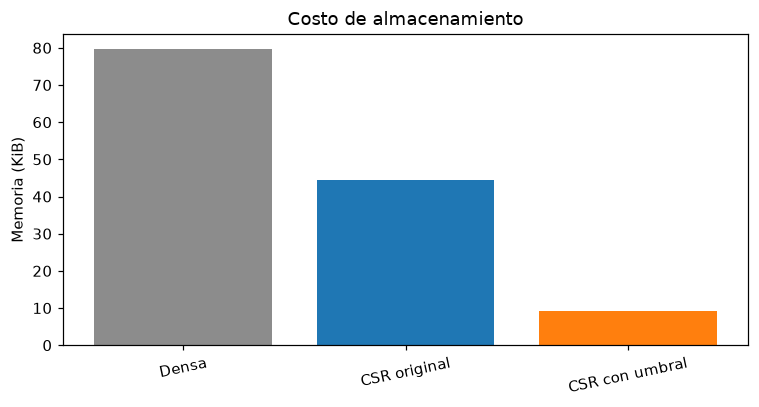

In [10]:
def bytes_csr(A):
    return A.data.nbytes + A.indices.nbytes + A.indptr.nbytes

Z50_csr = sp.csr_matrix(Z_umbral)
memoria = pd.DataFrame({
    "representación": ["Densa", "CSR original", "CSR con umbral"],
    "bytes": [Z.nbytes, bytes_csr(Z_csr), bytes_csr(Z50_csr)]
})
memoria["KiB"] = memoria["bytes"] / 1024
print(memoria.to_string(index=False, formatters={"KiB": "{:.1f}".format}))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(memoria["representación"], memoria["KiB"],
       color=["0.55", "tab:blue", "tab:orange"])
ax.set_ylabel("Memoria (KiB)")
ax.set_title("Costo de almacenamiento")
ax.tick_params(axis="x", rotation=12)
plt.tight_layout()
plt.show()

### Actividad 2

Construya matrices aleatorias de \(1000\times1000\) con densidades 0.1%, 1%,
10% y 50%. Compare memoria densa y CSR. Determine empíricamente desde qué
densidad CSR deja de ser conveniente para el tipo de datos utilizado.

## 5. Lectura económica de filas y columnas

- La suma de una fila mide ventas intermedias del producto proveedor.
- La suma de una columna mide compras intermedias del sector usuario.
- El número de no nulos aproxima la diversidad de conexiones, no su magnitud.

In [11]:
ventas_intermedias = np.asarray(Z_csr.sum(axis=1)).ravel()
compras_intermedias = np.asarray(Z_csr.sum(axis=0)).ravel()
clientes = np.diff(Z_csr.indptr)
proveedores = np.diff(Z_csc.indptr)

resumen = pd.DataFrame({
    "sector": sectores,
    "produccion": produccion,
    "ventas_intermedias": ventas_intermedias,
    "compras_intermedias": compras_intermedias,
    "clientes_no_nulos": clientes,
    "proveedores_no_nulos": proveedores
})
resumen.nlargest(10, "ventas_intermedias")

,sector,produccion,ventas_intermedias,compras_intermedias,clientes_no_nulos,proveedores_no_nulos
61,Servicio de comercialización,48256,19535.0,16069.0,99,59
5,"Petróleo crudo, gas natural y servicios conexos",17387,15428.0,3053.0,28,44
38,Petróleo refinado,22081,13444.0,16928.0,90,39
0,Productos agrícolas,18648,11669.0,2951.0,34,35
63,Transporte terrestre,24641,11055.0,12345.0,94,30
82,"Servicios profesionales, científicos y técnicos",9826,9104.0,3790.0,97,53
77,Servicios financieros,13737,9076.0,3307.0,95,51
7,Productos minerales metálicos,48826,7359.0,13332.0,6,59
1,Animales vivos y productos pecuarios,9535,7159.0,3916.0,21,32
39,"Sustancias químicas básicas, plásticos y caucho",7933,6429.0,1966.0,63,47


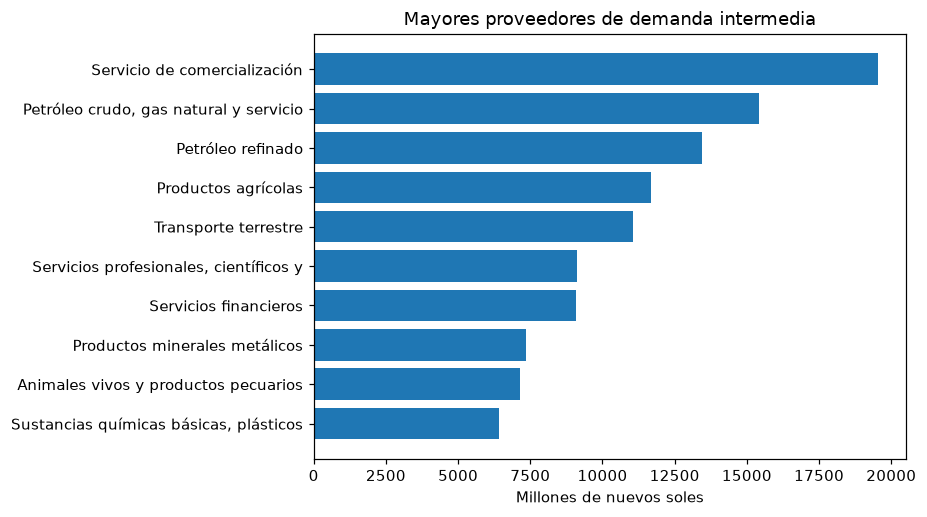

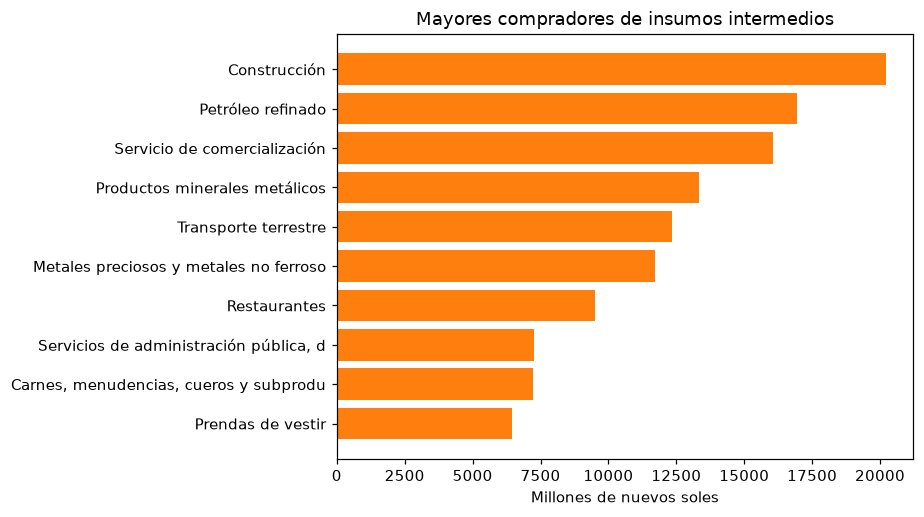

In [12]:
def barras_top(valores, titulo, color):
    idx = np.argsort(valores)[-10:]
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.barh([sectores[i][:38] for i in idx], valores[idx], color=color)
    ax.set_xlabel("Millones de nuevos soles")
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

barras_top(ventas_intermedias, "Mayores proveedores de demanda intermedia", "tab:blue")
barras_top(compras_intermedias, "Mayores compradores de insumos intermedios", "tab:orange")

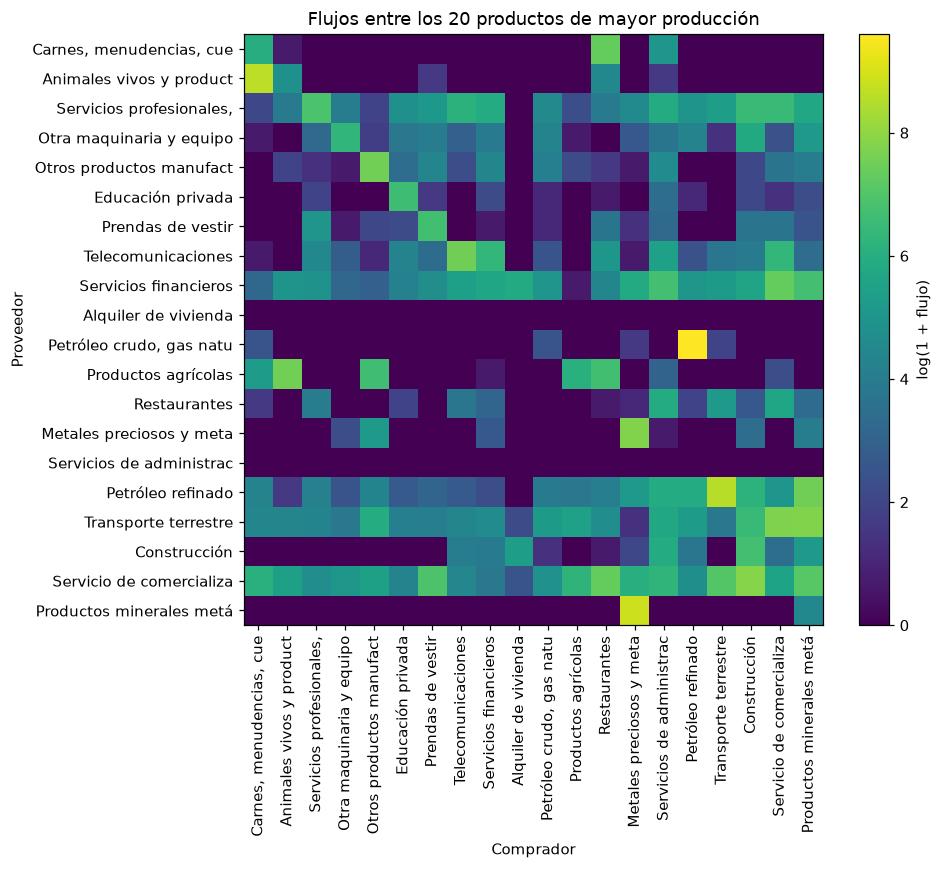

In [13]:
top = np.argsort(produccion)[-20:]
bloque = np.log1p(Z[np.ix_(top, top)])
etiquetas = [sectores[i][:24] for i in top]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(bloque, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(top)), etiquetas, rotation=90)
ax.set_yticks(range(len(top)), etiquetas)
ax.set_title("Flujos entre los 20 productos de mayor producción")
ax.set_xlabel("Comprador")
ax.set_ylabel("Proveedor")
fig.colorbar(im, ax=ax, label="log(1 + flujo)")
plt.tight_layout()
plt.show()

### Actividad 3

Compare los rankings por valor total y por número de conexiones. Identifique un
sector con pocas conexiones pero de gran magnitud y otro con muchas conexiones
pequeñas. Explique por qué grado y peso responden preguntas distintas.

## 6. Matriz dispersa de coeficientes técnicos

Definimos
\[
A=Z\operatorname{diag}(x)^{-1}.
\]
La entrada \(a_{ij}\) es el insumo del producto \(i\) necesario por unidad de
producción del sector \(j\). El equilibrio cumple
\[
(I-A)x=d.
\]

In [14]:
A_tecnica = Z_csr @ sp.diags(1.0 / produccion)
I = sp.eye(Z.shape[0], format="csr")
M_leontief = I - A_tecnica

error_modelo = np.linalg.norm(A_tecnica @ produccion + demanda_final - produccion)
rho = abs(spla.eigs(A_tecnica, k=1, which="LM",
                    return_eigenvectors=False)[0])

print("nnz(A):", A_tecnica.nnz)
print("rho(A):", rho)
print("Error del equilibrio Ax+d=x:", error_modelo)
assert rho < 1
assert np.allclose(A_tecnica @ produccion + demanda_final, produccion)

nnz(A): 3769
rho(A): 0.40486241388522454
Error del equilibrio Ax+d=x: 5.115907697472721e-13


In [15]:
x_sparse = spla.spsolve(M_leontief, demanda_final)
error_solucion = np.linalg.norm(x_sparse - produccion) / np.linalg.norm(produccion)
residuo = np.linalg.norm(M_leontief @ x_sparse - demanda_final) / np.linalg.norm(demanda_final)
print("Error relativo frente a la producción publicada:", error_solucion)
print("Residuo relativo:", residuo)
assert np.allclose(x_sparse, produccion)

Error relativo frente a la producción publicada: 2.244245894920291e-16
Residuo relativo: 3.040346883819084e-16


## 7. Choque de demanda final

Aumentaremos en 10% la demanda final asociada a construcción y observaremos
qué producciones reaccionan más, directa e indirectamente.

In [16]:
idx_construccion = next(i for i, nombre in enumerate(sectores)
                        if nombre.strip().lower() == "construcción")
d_escenario = demanda_final.copy()
d_escenario[idx_construccion] *= 1.10
x_escenario = spla.spsolve(M_leontief, d_escenario)
delta_x = x_escenario - produccion

print("Sector:", sectores[idx_construccion])
print("Aumento directo de demanda final:",
      d_escenario[idx_construccion] - demanda_final[idx_construccion])
print("Aumento total de producción:", delta_x.sum())

Sector: Construcción
Aumento directo de demanda final: 3638
Aumento total de producción: 6961.722315561492


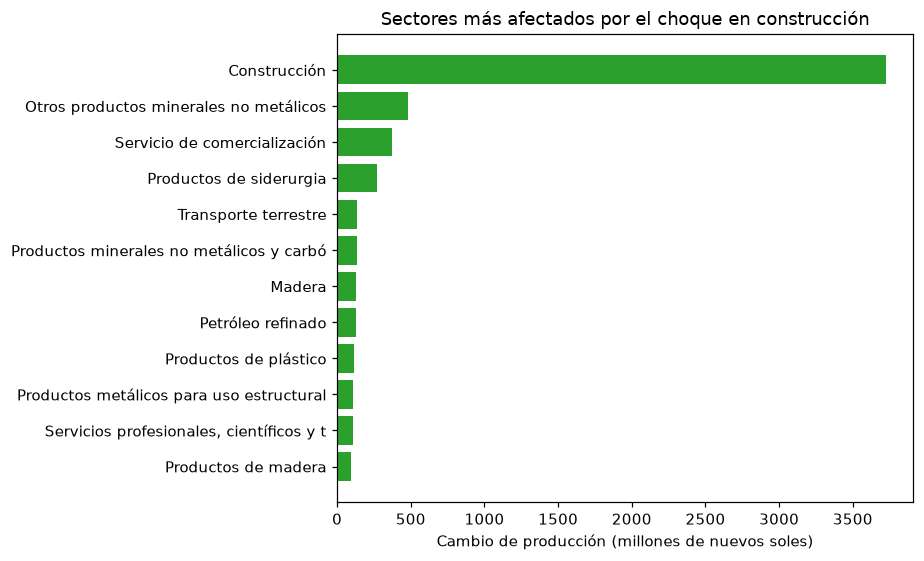

In [17]:
idx = np.argsort(delta_x)[-12:]
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.barh([sectores[i][:40] for i in idx], delta_x[idx], color="tab:green")
ax.set_xlabel("Cambio de producción (millones de nuevos soles)")
ax.set_title("Sectores más afectados por el choque en construcción")
plt.tight_layout()
plt.show()

### Actividad 4

Elija otro sector y diseñe un choque económicamente interpretable. Compare el
efecto directo con el efecto total. Identifique los cinco sectores con mayores
efectos indirectos y justifique el signo de los cambios.

## 8. Solución iterativa dispersa con GMRES

Un método de Krylov usa productos matriz–vector y evita una factorización densa.
Compararemos GMRES sin precondicionador y con un precondicionador diagonal.

In [18]:
historial_sin = []
x_gmres, info_sin = spla.gmres(
    M_leontief, demanda_final, rtol=1e-11, atol=0,
    callback=historial_sin.append, callback_type="pr_norm")

diagonal_M = M_leontief.diagonal()
P_jacobi = spla.LinearOperator(M_leontief.shape,
                               matvec=lambda v: v / diagonal_M)
historial_pre = []
x_pre, info_pre = spla.gmres(
    M_leontief, demanda_final, M=P_jacobi, rtol=1e-11, atol=0,
    callback=historial_pre.append, callback_type="pr_norm")

print("GMRES sin precondicionar:", info_sin, "iteraciones:", len(historial_sin))
print("GMRES con Jacobi        :", info_pre, "iteraciones:", len(historial_pre))
assert info_sin == 0 and info_pre == 0

GMRES sin precondicionar: 0 iteraciones: 15
GMRES con Jacobi        : 0 iteraciones: 15


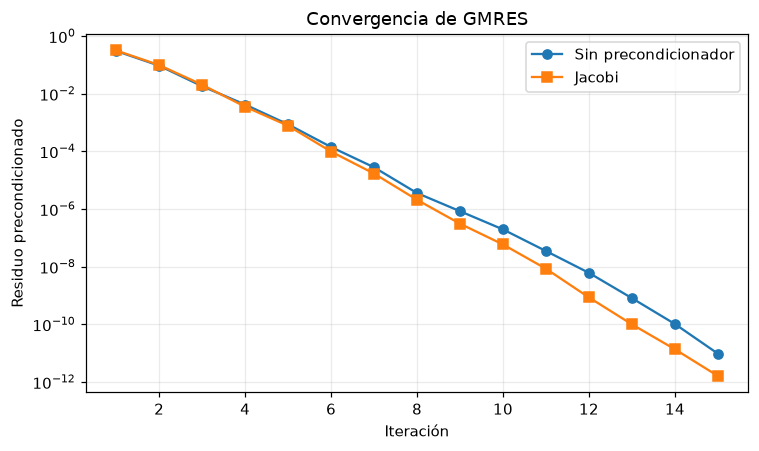

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(range(1, len(historial_sin) + 1), historial_sin,
            marker="o", label="Sin precondicionador")
ax.semilogy(range(1, len(historial_pre) + 1), historial_pre,
            marker="s", label="Jacobi")
ax.set_xlabel("Iteración")
ax.set_ylabel("Residuo precondicionado")
ax.set_title("Convergencia de GMRES")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

### Actividad 5

Compare GMRES para la matriz original y para una matriz técnica modificada cuyo
radio espectral esté más cerca de uno. Discuta iteraciones, condicionamiento y
la interpretación económica de acercarse al límite de productividad.

## 9. La matriz como red económica

Al ignorar magnitudes y conservar solo existencia de flujos, obtenemos una
matriz de adyacencia. La conectividad depende del umbral elegido.

In [20]:
adyacencia = Z50_csr.copy()
adyacencia.data[:] = 1
adyacencia = adyacencia.maximum(adyacencia.T)
n_componentes, etiquetas_componentes = connected_components(
    adyacencia, directed=False)
grados = np.asarray(adyacencia.sum(axis=1)).ravel()

print("Componentes conexas con umbral", umbral, ":", n_componentes)
print("Sectores aislados:", np.count_nonzero(grados == 0))
print("Grado mediano:", np.median(grados), "grado máximo:", grados.max())

Componentes conexas con umbral 50.0 : 4
Sectores aislados: 2
Grado mediano: 9.0 grado máximo: 78.0


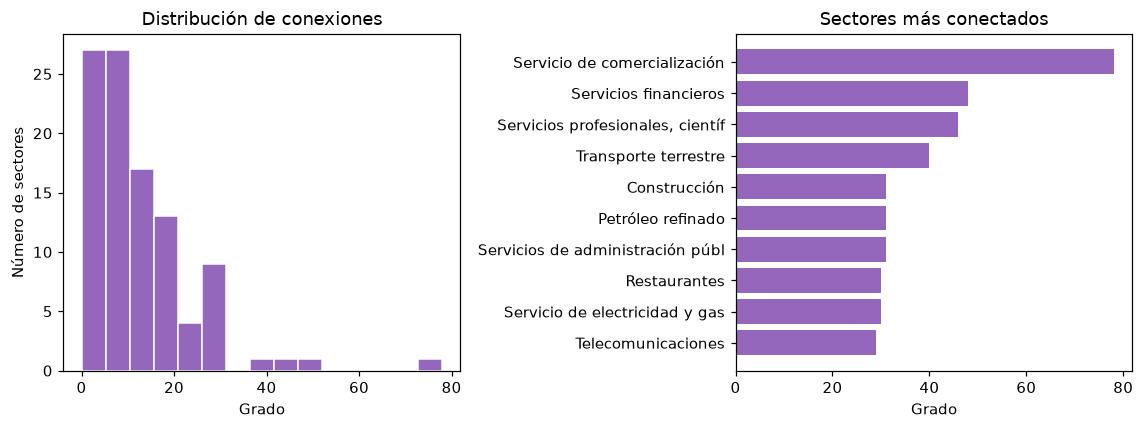

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
axes[0].hist(grados, bins=15, color="tab:purple", edgecolor="white")
axes[0].set_xlabel("Grado")
axes[0].set_ylabel("Número de sectores")
axes[0].set_title("Distribución de conexiones")

idx = np.argsort(grados)[-10:]
axes[1].barh([sectores[i][:32] for i in idx], grados[idx], color="tab:purple")
axes[1].set_xlabel("Grado")
axes[1].set_title("Sectores más conectados")
plt.tight_layout()
plt.show()

### Actividad 6

Construya una tabla para varios umbrales con número de enlaces, componentes,
aislados y grado máximo. Explique por qué una conclusión sobre centralidad debe
indicar siempre cómo se definió un enlace.

## 10. Persistencia y operaciones que deben evitarse

SciPy permite guardar una matriz sin expandirla. Convertir indiscriminadamente
a densa o formar una inversa puede destruir la ventaja de la dispersidad.

In [22]:
ruta_npz = Path("mip_tecnica_inei_2007.npz")
sp.save_npz(ruta_npz, A_tecnica)
A_recuperada = sp.load_npz(ruta_npz)
print("Archivo temporal:", ruta_npz, "nnz:", A_recuperada.nnz)
assert np.allclose(A_recuperada.toarray(), A_tecnica.toarray())
ruta_npz.unlink()

Archivo temporal: mip_tecnica_inei_2007.npz nnz: 3769


### Buenas prácticas

- Conserve CSR para productos matriz–vector y sistemas.
- Use CSC cuando predominen accesos por columnas.
- Evite formar \(A^{-1}\): resuelva sistemas.
- Evite convertir matrices grandes a densas para visualizarlas.
- Documente unidades, umbrales y tratamiento de valores faltantes.
- Compruebe residuo, balance económico y forma de la matriz.

## 11. Entrega

Entregue el cuaderno ejecutado con:

1. respuestas a las seis actividades;
2. tres visualizaciones propias;
3. un choque de demanda final con interpretación;
4. comparación de memoria densa y CSR;
5. comparación de solución directa dispersa y GMRES;
6. una nota metodológica sobre las limitaciones de usar la tabla de 2007.

### Lista de verificación

- [ ] Se preservó el archivo oficial sin modificar.
- [ ] Se informó el umbral en toda visualización de red.
- [ ] No se confundió cero observado con flujo económicamente imposible.
- [ ] Se validó \(Z\mathbf 1+d=x\).
- [ ] Se reportó el residuo de cada sistema resuelto.

In [23]:
print("Laboratorio de matrices dispersas ejecutado hasta el final.")
print("Complete las actividades y conserve las unidades económicas.")

Laboratorio de matrices dispersas ejecutado hasta el final.
Complete las actividades y conserve las unidades económicas.
